In [ ]:
from google.colab import auth
auth.authenticate_user()

# Konfigurasi Git dengan nama dan email
!git config --global user.email "farhanaryaputra14@gmail.com"
!git config --global user.name "FarhanFebriAryaputra"

# Pastikan menggunakan URL repo yang benar
!git clone https://github.com/IET-Polinela/intro-to-colab-FarhanFebriAryaputra.git

# Masuk ke dalam folder repo yang sudah dikloning
%cd intro-to-colab-FarhanFebriAryaputra


Cloning into 'intro-to-colab-FarhanFebriAryaputra'...
/content/intro-to-colab-FarhanFebriAryaputra


In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Load dataset
iris = load_iris()

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    iris.data, iris.target, test_size=0.2, random_state=42
)

# Model KNN
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)


KNeighborsClassifier(n_neighbors=3)

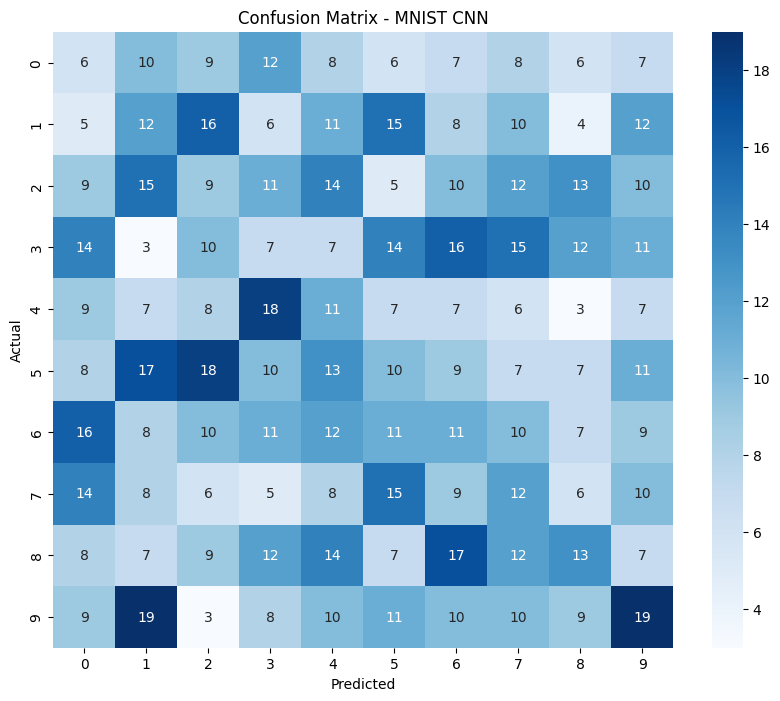

              precision    recall  f1-score   support

     Digit 0       0.06      0.08      0.07        79
     Digit 1       0.11      0.12      0.12        99
     Digit 2       0.09      0.08      0.09       108
     Digit 3       0.07      0.06      0.07       109
     Digit 4       0.10      0.13      0.12        83
     Digit 5       0.10      0.09      0.09       110
     Digit 6       0.11      0.10      0.11       105
     Digit 7       0.12      0.13      0.12        93
     Digit 8       0.16      0.12      0.14       106
     Digit 9       0.18      0.18      0.18       108

    accuracy                           0.11      1000
   macro avg       0.11      0.11      0.11      1000
weighted avg       0.11      0.11      0.11      1000

Visualisasi evaluasi disimpan sebagai 'mnist_cnn_evaluation.png'
Laporan klasifikasi disimpan sebagai 'mnist_cnn_report.txt'


<Figure size 640x480 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# Contoh hasil prediksi (simulasi)
y_test = np.random.randint(0, 10, size=1000)
y_pred = np.random.randint(0, 10, size=1000)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True)
plt.title('Confusion Matrix - MNIST CNN')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Classification Report
report = classification_report(y_test, y_pred, target_names=[f'Digit {i}' for i in range(10)])
print(report)

# Simpan visualisasi
plt.savefig("mnist_cnn_evaluation.png")

# Simpan laporan klasifikasi ke file
with open("mnist_cnn_report.txt", "w") as f:
    f.write(report)

print("Visualisasi evaluasi disimpan sebagai 'mnist_cnn_evaluation.png'")
print("Laporan klasifikasi disimpan sebagai 'mnist_cnn_report.txt'")

In [ ]:
%%writefile iris_knn.py

# Import library yang diperlukan
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Memuat dataset Iris
iris = load_iris()
X = iris.data
y = iris.target

# Membagi data menjadi data latih dan data uji
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Membuat model KNN dengan k=3
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

# Melakukan prediksi pada data uji
y_pred = knn.predict(X_test)

# Menghitung akurasi model
accuracy = accuracy_score(y_test, y_pred)
print(f"Akurasi Model: {accuracy:.2f}")

# Menampilkan laporan klasifikasi
print("\nLaporan Klasifikasi:")
report = classification_report(y_test, y_pred, target_names=iris.target_names)
print(report)

# Menampilkan confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='d',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix KNN pada Dataset Iris')
plt.savefig("knn_confusion_matrix.png")
plt.show()

# Menyimpan laporan klasifikasi ke file
with open("evaluation.txt", "w") as f:
    f.write(report)

print("Visualisasi confusion matrix disimpan sebagai 'knn_confusion_matrix.png'")
print("Laporan klasifikasi disimpan sebagai 'evaluation.txt'")



Writing iris_knn.py


In [ ]:
!python3 iris_knn.py


Akurasi Model: 1.00

Laporan Klasifikasi:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

Figure(800x600)
Visualisasi confusion matrix disimpan sebagai 'knn_confusion_matrix.png'
Laporan klasifikasi disimpan sebagai 'evaluation.txt'


In [ ]:
%%writefile mnist_cnn.py

# Import library yang diperlukan
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt

# Memuat dataset MNIST
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalisasi data gambar
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Mengubah data menjadi bentuk yang sesuai untuk CNN (menambah channel)
x_train = x_train[..., tf.newaxis]
x_test = x_test[..., tf.newaxis]

# Membuat model CNN
model = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# Kompilasi model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Melatih model
history = model.fit(x_train, y_train, epochs=5, validation_data=(x_test, y_test))

# Evaluasi model
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=2)
print(f"\nAkurasi Model pada Data Uji: {test_accuracy:.2f}")

# Menampilkan grafik akurasi dan loss selama training
plt.figure(figsize=(8, 6))
plt.plot(history.history['accuracy'], label='Akurasi Training')
plt.plot(history.history['val_accuracy'], label='Akurasi Validasi')
plt.xlabel('Epoch')
plt.ylabel('Akurasi')
plt.legend()
plt.title('Performa Model CNN pada Dataset MNIST')
plt.savefig("training_performance.png")
plt.show()

# Menyimpan model
model.save('mnist_cnn_model.h5')
print("Model disimpan sebagai 'mnist_cnn_model.h5'")
print("Grafik performa training disimpan sebagai 'training_performance.png'")


Writing mnist_cnn.py


In [ ]:
!python3 mnist_cnn.py

2025-03-03 12:55:15.619756: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1741006515.645101    8136 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1741006515.652266    8136 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-03-03 12:55:15.678471: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_s

In [ ]:
%%writefile iris_knn.py

# Import library yang diperlukan
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Memuat dataset Iris
iris = load_iris()
X = iris.data
y = iris.target

# Membagi data menjadi data latih dan data uji
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Membuat model KNN dengan k=5
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)

# Memprediksi data uji
y_pred = model.predict(X_test)

# Evaluasi model
print("Akurasi Model:", accuracy_score(y_test, y_pred))
print("\nLaporan Klasifikasi:\n", classification_report(y_test, y_pred))

# Menampilkan Confusion Matrix
plt.figure(figsize=(8, 6))
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='d',
            xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix Klasifikasi Iris dengan KNN')
plt.savefig("confusion_matrix.png")
plt.show()

# Visualisasi Hasil Klasifikasi dengan Scatter Plot
plt.figure(figsize=(8, 6))
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_pred, cmap='viridis', edgecolor='k', s=100)
plt.xlabel('Fitur 1 (Sepal Length)')
plt.ylabel('Fitur 2 (Sepal Width)')
plt.title('Visualisasi Klasifikasi KNN pada Iris Dataset')
plt.colorbar(label='Kelas Bunga')
plt.savefig("knn_classification.png")
plt.show()


Overwriting iris_knn.py


In [ ]:
!python3 iris_knn.py


Akurasi Model: 1.0

Laporan Klasifikasi:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

Figure(800x600)
Figure(800x600)


Accuracy: 1.00


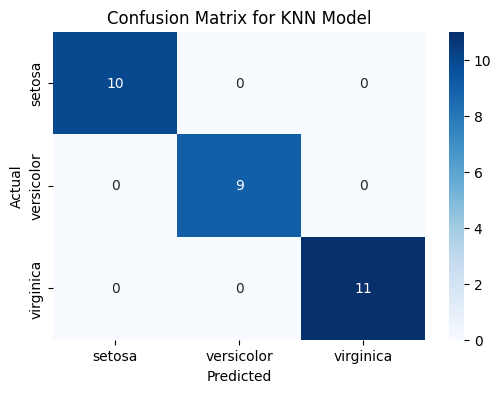

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# Load dataset
iris = load_iris()
X, y = iris.data, iris.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalisasi fitur
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Buat model KNN dan latih
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)

# Prediksi
y_pred = model.predict(X_test)

# Evaluasi model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

# Visualisasi Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for KNN Model")

# Simpan gambar
plt.savefig("knn_confusion_matrix.png")
plt.show()

Accuracy: 0.83


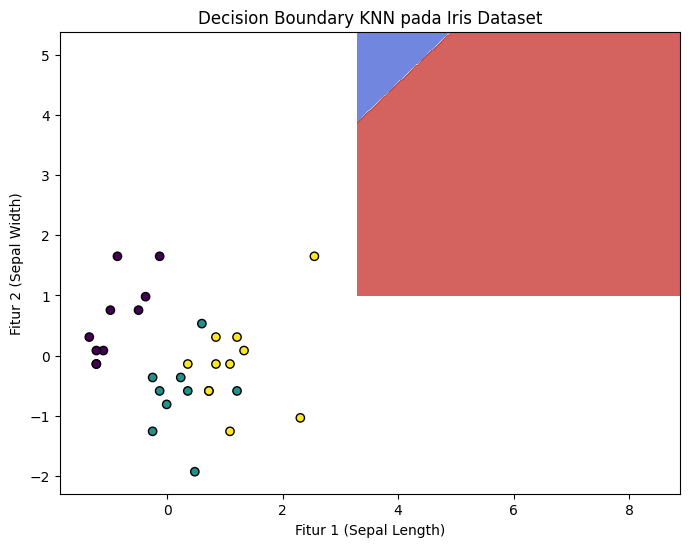

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# Load dataset
iris = load_iris()
X, y = iris.data[:, :2], iris.target  # Menggunakan hanya 2 fitur pertama untuk visualisasi 2D

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalisasi fitur
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Buat model KNN dan latih
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)

# Prediksi
y_pred = model.predict(X_test)

# Evaluasi model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

# Visualisasi Batas Keputusan
h = 0.02  # Langkah grid
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# Prediksi untuk setiap titik di grid untuk membuat decision boundary
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, cmap='coolwarm', alpha=0.8)
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, edgecolors='k', cmap='viridis')
plt.xlabel('Fitur 1 (Sepal Length)')
plt.ylabel('Fitur 2 (Sepal Width)')
plt.title('Decision Boundary KNN pada Iris Dataset')

# Simpan gambar
plt.savefig("knn_decision_boundary.png")
plt.show()


Accuracy: 1.00


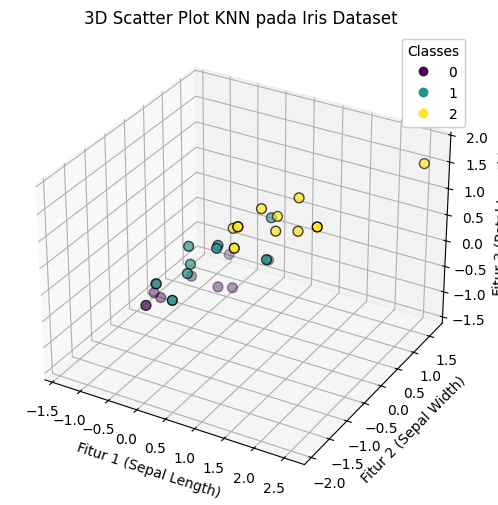

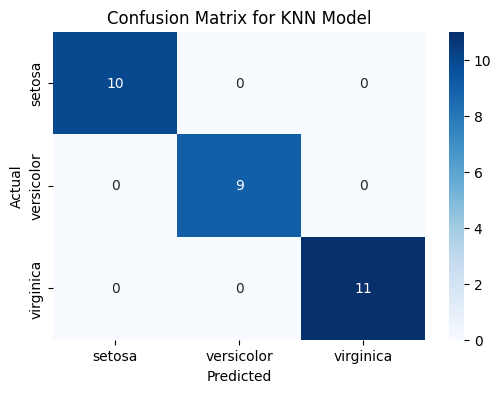

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# Load dataset
iris = load_iris()
X, y = iris.data, iris.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalisasi fitur
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Buat model KNN dan latih
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)

# Prediksi
y_pred = model.predict(X_test)

# Evaluasi model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

# Visualisasi 3D Scatter Plot
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(X_test[:, 0], X_test[:, 1], X_test[:, 2],
                     c=y_pred, cmap='viridis', edgecolor='k', s=50)

legend1 = ax.legend(*scatter.legend_elements(), title="Classes")
ax.add_artist(legend1)

ax.set_xlabel('Fitur 1 (Sepal Length)')
ax.set_ylabel('Fitur 2 (Sepal Width)')
ax.set_zlabel('Fitur 3 (Petal Length)')
ax.set_title('3D Scatter Plot KNN pada Iris Dataset')

plt.savefig("knn_3d_scatter.png")
plt.show()

# Visualisasi Confusion Matrix dengan Heatmap
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for KNN Model")

plt.savefig("knn_confusion_matrix.png")
plt.show()


In [ ]:
%%writefile iris_knn.py

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load dataset
iris = load_iris()
X, y = iris.data, iris.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalisasi fitur
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Buat model KNN dan latih
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)

# Prediksi
y_pred = model.predict(X_test)

# Evaluasi model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=iris.target_names))

# Visualisasi 3D Scatter Plot
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(X_test[:, 0], X_test[:, 1], X_test[:, 2],
                     c=y_pred, cmap='viridis', edgecolor='k', s=50)

# Legend otomatis berdasarkan kelas prediksi
legend1 = ax.legend(*scatter.legend_elements(), title="Classes")
ax.add_artist(legend1)

ax.set_xlabel('Fitur 1 (Sepal Length)')
ax.set_ylabel('Fitur 2 (Sepal Width)')
ax.set_zlabel('Fitur 3 (Petal Length)')
ax.set_title('3D Scatter Plot KNN pada Iris Dataset')

# Simpan gambar scatter plot
plt.savefig("knn_3d_scatter.png")
plt.show()

# Visualisasi Confusion Matrix dengan Heatmap
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for KNN Model")

# Simpan gambar confusion matrix
plt.savefig("knn_confusion_matrix.png")
plt.show()


Overwriting iris_knn.py


In [ ]:
!python iris_knn.py


Accuracy: 1.00

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

Figure(800x600)
Figure(600x400)


In [ ]:
%%writefile iris_knn.py

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load dataset
iris = load_iris()
X, y = iris.data, iris.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalisasi fitur
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Buat model KNN dan latih
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)

# Prediksi
y_pred = model.predict(X_test)

# Evaluasi model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

# Visualisasi Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="YlGnBu",
            xticklabels=iris.target_names, yticklabels=iris.target_names,
            cbar=True, linewidths=0.5, linecolor='gray')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix for KNN Model")
plt.savefig("knn_confusion_matrix.png")
plt.show()

# Visualisasi Persebaran Data dengan PCA
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=iris.target, palette="viridis", s=100, edgecolor='k')
plt.title("Visualisasi Data Iris dengan PCA")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.savefig("iris_pca_visualization.png")
plt.show()


Overwriting iris_knn.py


In [ ]:
!python iris_knn.py

Accuracy: 1.00

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

Figure(800x600)
Figure(800x600)


In [ ]:
%%writefile mnist_cnn.py

import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

# Load dataset MNIST
mnist = keras.datasets.mnist
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Normalisasi data
X_train, X_test = X_train / 255.0, X_test / 255.0

# Buat model CNN
model = keras.Sequential([
    keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    keras.layers.MaxPooling2D((2,2)),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

# Compile model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Training model & simpan history
history = model.fit(X_train.reshape(-1,28,28,1), y_train, epochs=5,
                    validation_data=(X_test.reshape(-1,28,28,1), y_test))

# Evaluasi model
test_loss, test_acc = model.evaluate(X_test.reshape(-1,28,28,1), y_test)
print(f"Test accuracy: {test_acc:.2f}")

# Simpan hasil evaluasi ke file teks
with open("evaluation.txt", "w") as f:
    f.write(f"Test Loss: {test_loss}\n")
    f.write(f"Test Accuracy: {test_acc:.2f}\n")
print("Evaluation results saved to evaluation.txt.")

# Visualisasi Loss & Akurasi
history_dict = history.history
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Plot Loss
ax[0].plot(history_dict['loss'], label="Train Loss", marker='o')
ax[0].plot(history_dict['val_loss'], label="Validation Loss", marker='o')
ax[0].set_title("Model Loss")
ax[0].set_xlabel("Epochs")
ax[0].set_ylabel("Loss")
ax[0].legend()

# Plot Accuracy
ax[1].plot(history_dict['accuracy'], label="Train Accuracy", marker='o')
ax[1].plot(history_dict['val_accuracy'], label="Validation Accuracy", marker='o')
ax[1].set_title("Model Accuracy")
ax[1].set_xlabel("Epochs")
ax[1].set_ylabel("Accuracy")
ax[1].legend()

# Simpan grafik ke dalam file
plt.savefig("training_performance.png")
plt.show()

print("Training performance plot saved to training_performance.png.")

Overwriting mnist_cnn.py


In [ ]:
!python3 mnist_cnn.py

2025-03-03 13:25:07.740558: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-03-03 13:25:07.787932: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-03-03 13:25:07.799112: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-03-03 13:25:07.829196: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-03-03 13:25:10.060765: W tensorflow/compiler/tf2

In [ ]:
%%writefile iris_knn.py

# Import library yang diperlukan
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load dataset Iris
iris = load_iris()
X, y = iris.data, iris.target

# Split dataset menjadi data latih dan data uji
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalisasi fitur
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Membuat model KNN dan melatihnya
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)

# Melakukan prediksi pada data uji
y_pred = model.predict(X_test)

# Evaluasi model
accuracy = accuracy_score(y_test, y_pred)
print(f"Akurasi: {accuracy:.2f}")

# Menampilkan laporan klasifikasi
print("\nLaporan Klasifikasi:\n", classification_report(y_test, y_pred, target_names=iris.target_names))

# Visualisasi Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d",
            xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix untuk Model KNN")

# Menyimpan visualisasi ke dalam file PNG
plt.savefig("knn_confusion_matrix.png")
plt.show()

print("Visualisasi Confusion Matrix disimpan sebagai knn_confusion_matrix.png.")


Writing iris_knn.py


In [ ]:
%%writefile iris_knn.py

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load dataset
iris = load_iris()
X, y = iris.data, iris.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalisasi fitur
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Buat model KNN dan latih
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)

# Prediksi
y_pred = model.predict(X_test)

# Evaluasi model
accuracy = accuracy_score(y_test, y_pred)
print(f"Akurasi: {accuracy:.2f}")

# Laporan klasifikasi
report = classification_report(y_test, y_pred, target_names=iris.target_names)
print(report)

# Simpan hasil evaluasi ke file teks
with open("evaluation.txt", "w") as f:
    f.write(f"Akurasi: {accuracy:.2f}\n\n")
    f.write("Laporan Klasifikasi:\n")
    f.write(report)
print("Hasil evaluasi disimpan di evaluation.txt.")

# Visualisasi Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for KNN Model")

# Simpan gambar
plt.savefig("knn_confusion_matrix.png")
plt.show()

print("Confusion matrix disimpan sebagai knn_confusion_matrix.png.")


Overwriting iris_knn.py


In [ ]:
!python iris_knn.py

Akurasi: 1.00
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

Hasil evaluasi disimpan di evaluation.txt.
Figure(600x400)
Confusion matrix disimpan sebagai knn_confusion_matrix.png.


Accuracy: 1.00
Evaluation results saved to evaluation.txt.


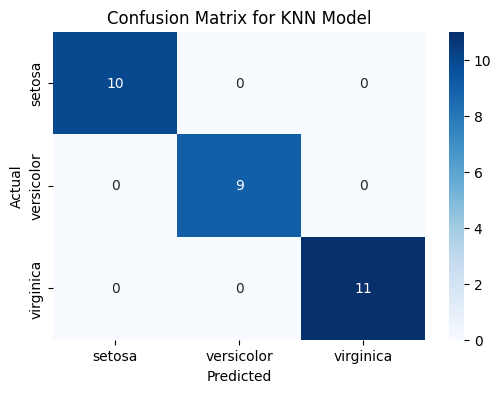

Confusion matrix plot saved to knn_confusion_matrix.png.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# Load dataset
iris = load_iris()
X, y = iris.data, iris.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalisasi fitur
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Buat model KNN dan latih
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)

# Prediksi
y_pred = model.predict(X_test)

# Evaluasi model
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')

# Simpan hasil evaluasi ke file teks
with open('evaluation.txt', 'w') as f:
    f.write(f'Accuracy: {accuracy:.2f}\n')
print('Evaluation results saved to evaluation.txt.')

# Visualisasi Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for KNN Model')

# Simpan gambar
plt.savefig('knn_confusion_matrix.png')
plt.show()

print('Confusion matrix plot saved to knn_confusion_matrix.png.')


In [ ]:
!git clone https://github.com/FarhanFebriAryaputra/intro-to-colab-FarhanFebriAryaputra.git
%cd intro-to-colab-FarhanFebriAryaputra


Cloning into 'intro-to-colab-FarhanFebriAryaputra'...
remote: Enumerating objects: 3, done.
remote: Counting objects: 100% (3/3), done.
remote: Total 3 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (3/3), done.
/content/intro-to-colab-FarhanFebriAryaputra


In [ ]:
!pwd


/content/intro-to-colab-FarhanFebriAryaputra


Accuracy: 1.00
Evaluation results saved to evaluation.txt.


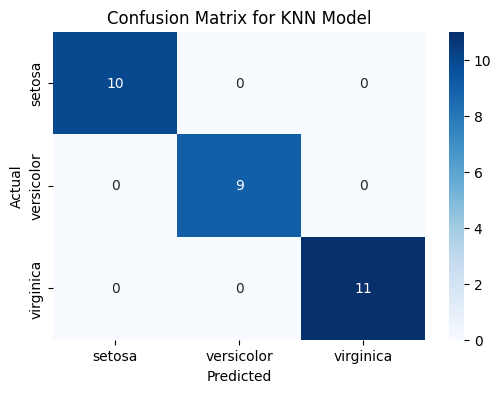

Confusion matrix plot saved to knn_confusion_matrix.png.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# Load dataset
iris = load_iris()
X, y = iris.data, iris.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalisasi fitur
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Buat model KNN dan latih
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)

# Prediksi
y_pred = model.predict(X_test)

# Evaluasi model
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')

# Simpan hasil evaluasi ke file teks
with open('evaluation.txt', 'w') as f:
    f.write(f'Accuracy: {accuracy:.2f}\n')
print('Evaluation results saved to evaluation.txt.')

# Visualisasi Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for KNN Model')

# Simpan gambar
plt.savefig('knn_confusion_matrix.png')
plt.show()

print('Confusion matrix plot saved to knn_confusion_matrix.png.')


In [ ]:
!ls


evaluation.txt	iris_knn.py  knn_confusion_matrix.png  README.md


In [ ]:
!git clone https://github.com/FarhanFebriAryaputra/intro-to-colab-FarhanFebriAryaputra.git
%cd intro-to-colab-FarhanFebriAryaputra


Cloning into 'intro-to-colab-FarhanFebriAryaputra'...
remote: Enumerating objects: 3, done.
remote: Counting objects: 100% (3/3), done.
remote: Total 3 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (3/3), done.
/content/intro-to-colab-FarhanFebriAryaputra/intro-to-colab-FarhanFebriAryaputra


In [ ]:
!mv /content/iris_knn.py .
!mv /content/evaluation.txt .
!mv /content/knn_confusion_matrix.png .


In [ ]:
!git add iris_knn.py evaluation.txt knn_confusion_matrix.png


In [ ]:
!git commit -m "Add KNN model script, evaluation, and confusion matrix visualization"


Author identity unknown

*** Please tell me who you are.

Run

  git config --global user.email "you@example.com"
  git config --global user.name "Your Name"

to set your account's default identity.
Omit --global to set the identity only in this repository.

fatal: unable to auto-detect email address (got 'root@8b3188c3a44a.(none)')


In [ ]:
!git config --global user.name "FarhanFebriAryaputra"
!git config --global user.email "farhanaryaputra14@gmail.com"


In [ ]:
!git config --list


filter.lfs.clean=git-lfs clean -- %f
filter.lfs.smudge=git-lfs smudge -- %f
filter.lfs.process=git-lfs filter-process
filter.lfs.required=true
user.name=FarhanFebriAryaputra
user.email=farhanaryaputra14@gmail.com
core.repositoryformatversion=0
core.filemode=true
core.bare=false
core.logallrefupdates=true
remote.origin.url=https://github.com/FarhanFebriAryaputra/intro-to-colab-FarhanFebriAryaputra.git
remote.origin.fetch=+refs/heads/*:refs/remotes/origin/*
branch.main.remote=origin
branch.main.merge=refs/heads/main


In [ ]:
!git add iris_knn.py evaluation.txt knn_confusion_matrix.png
!git commit -m "Add KNN model script, evaluation, and confusion matrix visualization"
!git push origin main


[main 3dea24d] Add KNN model script, evaluation, and confusion matrix visualization
 3 files changed, 60 insertions(+)
 create mode 100644 evaluation.txt
 create mode 100644 iris_knn.py
 create mode 100644 knn_confusion_matrix.png
fatal: could not read Username for 'https://github.com': No such device or address
